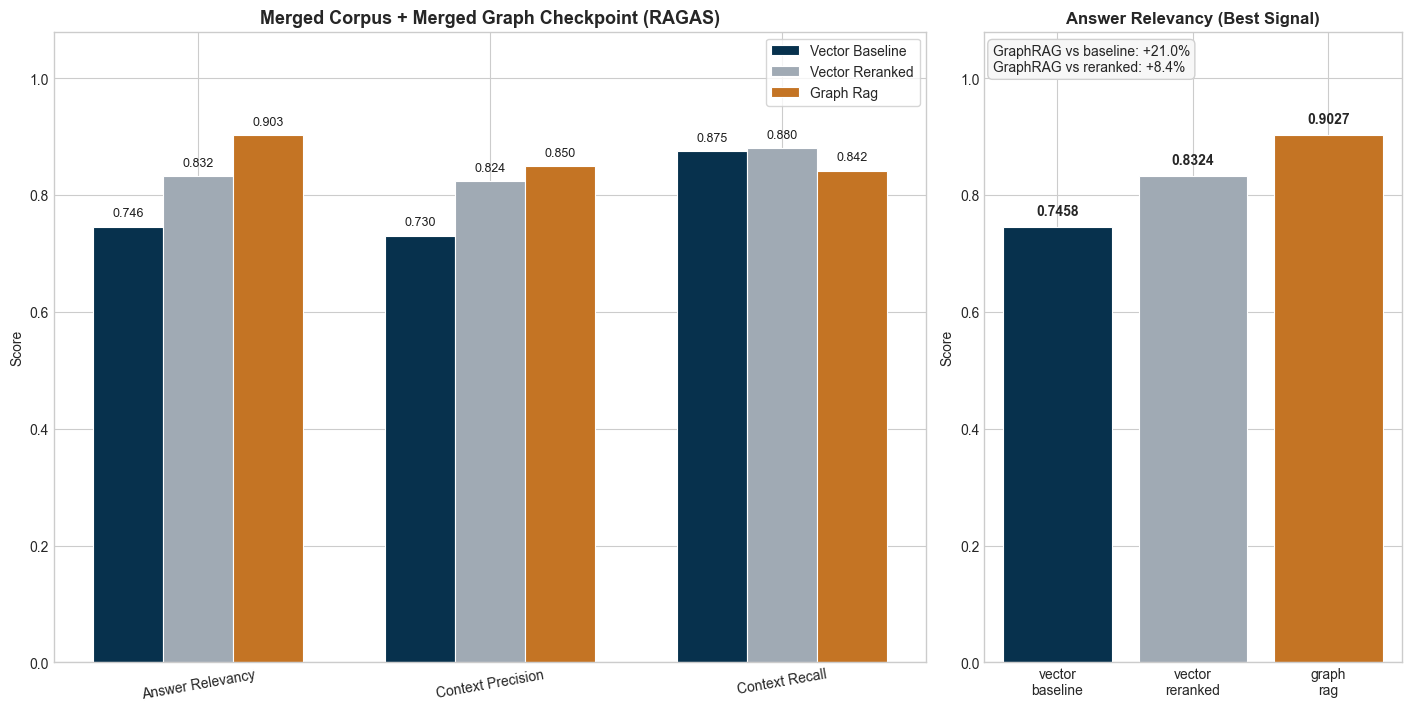

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Trusted merged benchmark results (RAGAS)
systems = ["vector_baseline", "vector_reranked", "graph_rag"]
metrics = ["answer_relevancy", "context_precision", "context_recall"]

scores = {
    "vector_baseline": [0.7458, 0.7304, 0.8750],
    "vector_reranked": [0.8324, 0.8243, 0.88],
    "graph_rag": [0.9027, 0.85, 0.8417],
}

# Requested palette: dark blue + orange (+ neutral support tone)
DARK_BLUE = "#07314D"
ORANGE = "#C47424"
NEUTRAL = "#A0AAB4"

color_map = {
    "vector_baseline": DARK_BLUE,
    "vector_reranked": NEUTRAL,
    "graph_rag": ORANGE,
}

plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(14, 7), constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[2.3, 1.1])

# ---- Left: grouped bars across all metrics ----
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(len(metrics))
bar_w = 0.24

for i, s in enumerate(systems):
    vals = scores[s]
    bars = ax1.bar(
        x + (i - 1) * bar_w,
        vals,
        width=bar_w,
        label=s.replace("_", " ").title(),
        color=color_map[s],
        edgecolor="white",
        linewidth=0.8,
    )
    for b, v in zip(bars, vals):
        ax1.text(
            b.get_x() + b.get_width() / 2,
            v + 0.012,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#1f1f1f",
        )

ax1.set_title("Merged Corpus + Merged Graph Checkpoint (RAGAS)", fontsize=13, weight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels([m.replace("_", " ").title() for m in metrics], rotation=10)
ax1.set_ylim(0, 1.08)
ax1.set_ylabel("Score")
ax1.legend(frameon=True, loc="upper right")

# ---- Right: answer relevancy spotlight ----
ax2 = fig.add_subplot(gs[0, 1])
answer_vals = [scores[s][0] for s in systems]
labels = [s.replace("_", "\n") for s in systems]
spot_colors = [color_map[s] for s in systems]

bars2 = ax2.bar(labels, answer_vals, color=spot_colors, edgecolor="white", linewidth=0.8)
for b, v in zip(bars2, answer_vals):
    ax2.text(
        b.get_x() + b.get_width() / 2,
        v + 0.015,
        f"{v:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold",
    )

# Improvement annotations vs baseline and reranked
baseline = scores["vector_baseline"][0]
reranked = scores["vector_reranked"][0]
graph = scores["graph_rag"][0]

vs_baseline = (graph - baseline) / baseline * 100
vs_reranked = (graph - reranked) / reranked * 100

ax2.set_title("Answer Relevancy (Best Signal)", fontsize=12, weight="bold")
ax2.set_ylim(0, 1.08)
ax2.set_ylabel("Score")
ax2.text(
    0.02,
    0.98,
    f"GraphRAG vs baseline: +{vs_baseline:.1f}%\nGraphRAG vs reranked: +{vs_reranked:.1f}%",
    transform=ax2.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#F7F7F7", edgecolor="#D0D0D0"),
)

plt.show()